## Peut-on prédire le risque de diabète de type 2 à partir de variables cliniques simples ?

## ⚙️ Statistique descriptive & Recall

### 1-Librairies et dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score

data = pd.read_csv("Data/diabetes_prediction_dataset_S8.csv")
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### 2-Statistique descriptive

In [10]:
data.describe()

data['diabetes'].value_counts(normalize=True)

diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

### 3-Visualisations exploratoires

#### 3.1-Distribution des variables

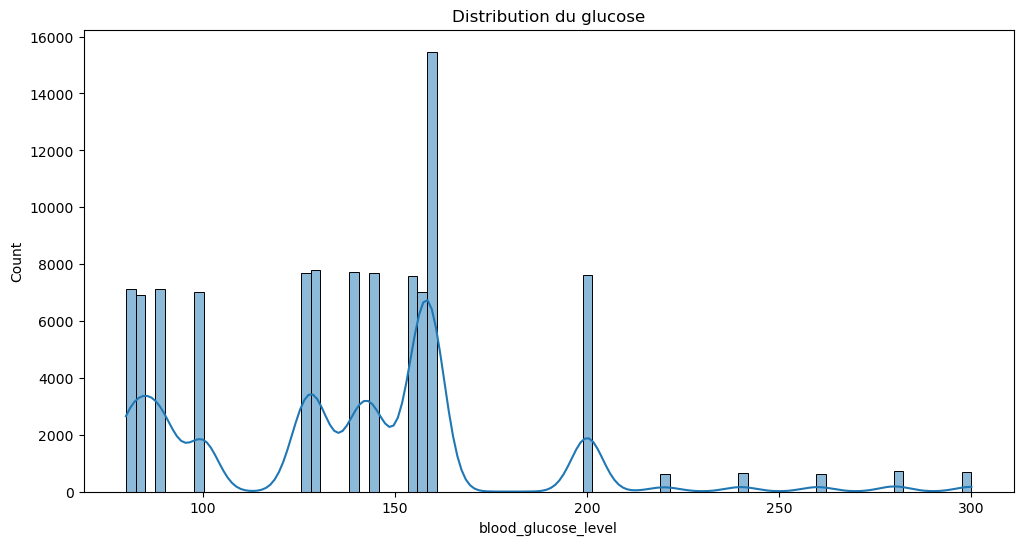

In [4]:
plt.figure(figsize=(12,6))
sns.histplot(data['blood_glucose_level'], kde=True)
plt.title("Distribution du glucose")
plt.show()

#### 3.2-Relation glucose & diabète

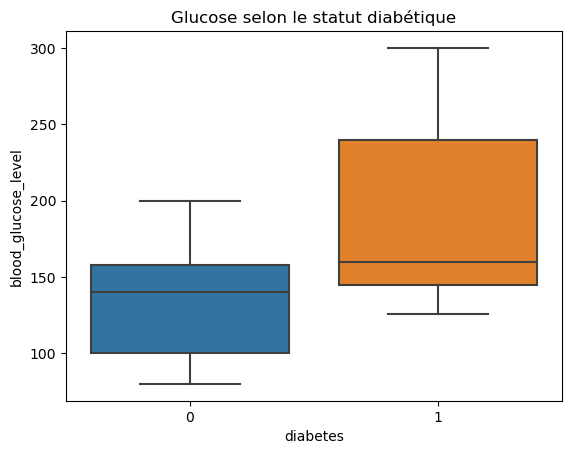

In [6]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=data)
plt.title("Glucose selon le statut diabétique")
plt.show()

### 4-Manipulation des données

In [17]:
data_encoded = pd.get_dummies(data, drop_first=True)

# Séparation X / y
X = data_encoded.drop('diabetes', axis=1)
y = data_encoded['diabetes']

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

### 5-Modèle

In [18]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

### 6-Evaluation avec focus sur le recall

In [19]:
# Rapport de classification
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [20]:
recall = recall_score(y_test, y_pred)
print(f"Recall (classe diabétique) : {recall:.3f}")

Recall (classe diabétique) : 0.639


### 7-Résumé

Les résultats montrent que des variables cliniques simples permettent de construire un modèle de régression logistique capable de détecter une proportion significative des cas de diabète de type 2.

Cependant, dans un contexte médical, la métrique la plus critique est le recall, car elle mesure la proportion de patients diabétiques correctement identifiés.
Ici, le modèle obtient un recall de 0.64 pour la classe diabétique, ce qui signifie qu’il détecte environ 64 % des cas réels. Ce résultat est encourageant : il montre que le modèle capture une majorité des patients à risque, tout en restant simple et interprétable.

Néanmoins, il laisse également une marge d’amélioration : près d’un tiers des cas diabétiques ne sont pas détectés. Dans une application réelle, on pourrait augmenter ce recall en ajustant le seuil de décision, en intégrant des variables cliniques supplémentaires ou en testant des modèles plus complexes.

En résumé, cette analyse démontre qu’il est possible de prédire le risque de diabète de type 2 à partir de données cliniques accessibles, et qu’un modèle simple comme la régression logistique peut déjà fournir une base solide pour un outil de dépistage précoce.